In [1]:
from mslandcover.data.datasets import PreTrainDataset, FineTuneDataset
from mslandcover.data.transforms import SimCLRDataAugmentation, HiResDataAugmentation, StandardDataAugmentations
from mslandcover.utils import load_pth
from torchvision.transforms import ColorJitter
import rasterio as rio
from glob import glob
import matplotlib.pyplot as plt
import torch
import numpy as np

plt.rcParams['font.family'] = 'serif'

# HiResCLR - 4 bands

In [2]:
pretrain_paths = glob('/scratch/dhester/mslc_data_v2/pretrain/*.tif')

mean = load_pth('./weights/pretrain_mean_4.pt')
std = load_pth('./weights/pretrain_std_4.pt')

def unnormalize(x, mean, std):
    x = x * std[:, None, None] + mean[:, None, None]
    return x

dataset = PreTrainDataset(
    data_paths=pretrain_paths,
    n_views=2,
    transform=HiResDataAugmentation(size=128),
    mean=load_pth('./weights/pretrain_mean_4.pt'),
    std=load_pth('./weights/pretrain_std_4.pt'),
    n_bands=4
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.030019939..1.2484895].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.013256967..0.74802214].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.013256967..0.74802214].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.067349315..1.1380959].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.055386066..1.0912334].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.055386066..1.2243495].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range 

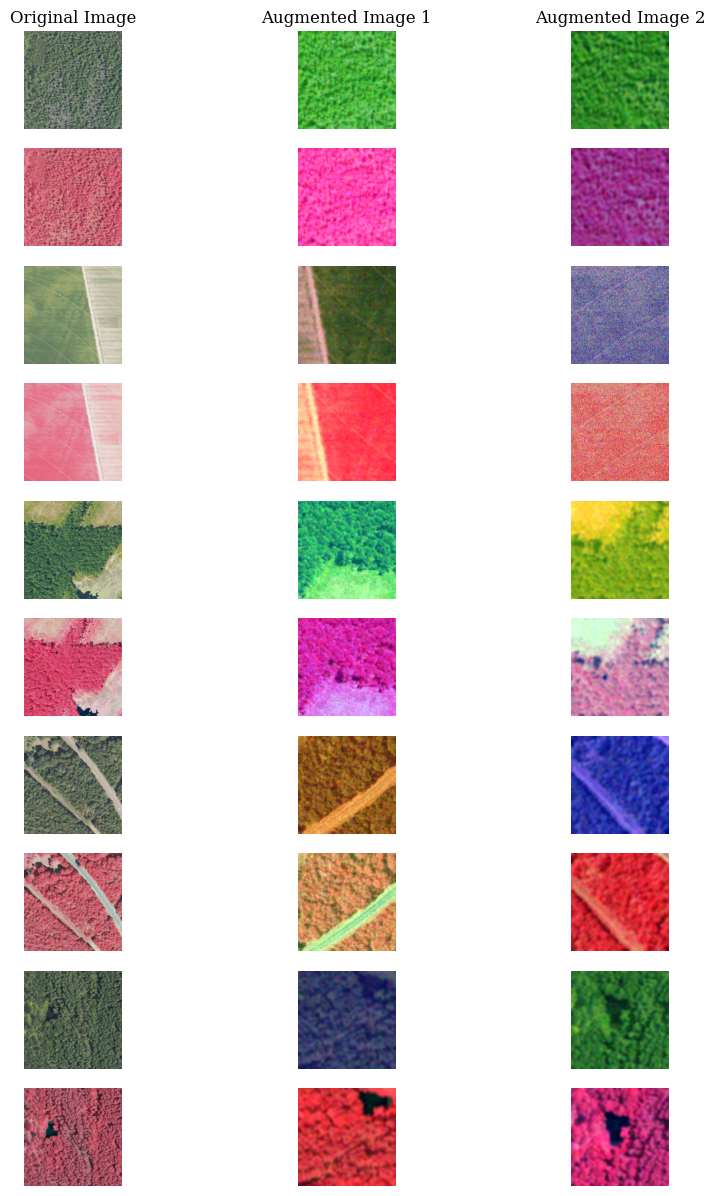

In [3]:
fig, ax = plt.subplots(10, 3, figsize=(10, 15))

for i in range(0, 10, 2):

    x_1, x_2 = dataset[i]
    x_1, x_2 = x_1[0], x_2[0]
    
    x_1, x_2 = unnormalize(x_1, mean, std), unnormalize(x_2, mean, std)

    x_og = rio.open(pretrain_paths[i]).read()
    x_og_rgb = x_og[:3, :, :].transpose(1, 2, 0)
    x_og_nir = np.stack([x_og[3, :, :], x_og[0, :, :], x_og[1, :, :]], axis=-1)
    
    x_1_rgb = x_1[:3, :, :].permute(1, 2, 0).numpy()
    x_2_rgb = x_2[:3, :, :].permute(1, 2, 0).numpy()
    
    x_1_nir = np.stack([x_1[3, :, :].numpy(), x_1[0, :, :].numpy(), x_1[1, :, :].numpy()], axis=-1)
    x_2_nir = np.stack([x_2[3, :, :].numpy(), x_2[0, :, :].numpy(), x_2[1, :, :].numpy()], axis=-1)

    ax[i][0].imshow(x_og_rgb)
    ax[i+1][0].imshow(x_og_nir)

    ax[i][1].imshow(x_1_rgb)
    ax[i+1][1].imshow(x_1_nir)

    ax[i][2].imshow(x_2_rgb)
    ax[i+1][2].imshow(x_2_nir)
    
    # how can I add a horzontal line between the two rows?
    
ax[0][0].set_title('Original Image')
ax[0][1].set_title('Augmented Image 1')
ax[0][2].set_title('Augmented Image 2')

for a in ax.flatten():
    a.axis('off')


# SimCLR - 3 bands

In [2]:
mean = load_pth('./weights/pretrain_mean.pth')
std = load_pth('./weights/pretrain_std.pth')

dataset = PreTrainDataset(
    data_paths=pretrain_paths,
    n_views=2,
    transform=SimCLRDataAugmentation(size=192),
    mean=mean,
    std=std,
    n_bands=3
)



def unnormalize(x, mean, std):
    x = x * std[:, None, None] + mean[:, None, None]
    return x

fig, ax = plt.subplots(10, 3, figsize=(10, 15))
for i in range(0, 10, 2):

    x_1, x_2 = dataset[i]
    x_1, x_2 = x_1[0], x_2[0]
    
    x_1, x_2 = unnormalize(x_1, mean, std), unnormalize(x_2, mean, std)

    x_og = rio.open(pretrain_paths[i]).read()
    x_og_rgb = x_og[:3, :, :].transpose(1, 2, 0)
    
    x_1_rgb = x_1[:3, :, :].permute(1, 2, 0).numpy()
    x_2_rgb = x_2[:3, :, :].permute(1, 2, 0).numpy()

    ax[i][0].imshow(x_og_rgb)
    ax[i+1][0].imshow(x_og_rgb)

    ax[i][1].imshow(x_1_rgb)
    ax[i+1][1].imshow(x_1_rgb)

    ax[i][2].imshow(x_2_rgb)
    ax[i+1][2].imshow(x_2_rgb)

NameError: name 'pretrain_paths' is not defined

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15398532..1.0268514].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.037434638..1.0156674].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10885769..0.8632306].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.57102656..1.1096696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2806192..1.1576285].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05621761..0.7166749].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07

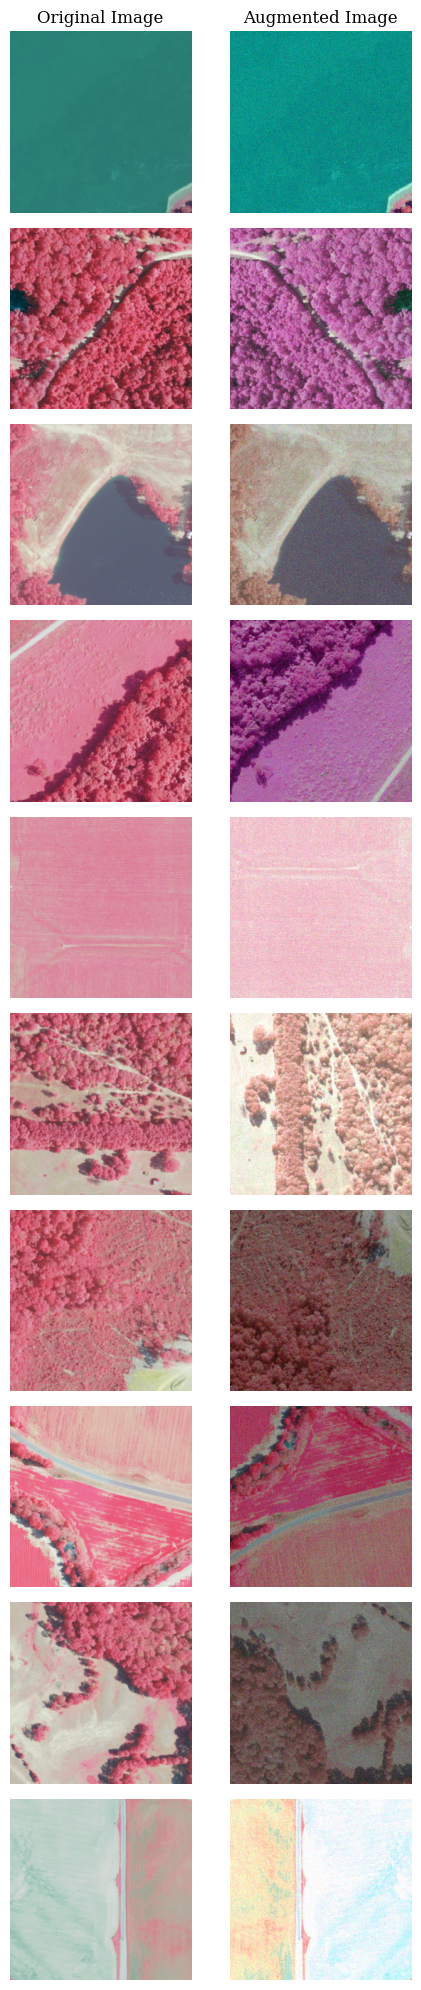

In [ ]:
mean = load_pth('./weights/pretrain_mean.pth')
std = load_pth('./weights/pretrain_std.pth')

dataset = FineTuneDataset(
    data_paths=glob('./data/splits/split_1/input/*.tif'),
    target_paths=glob('./data/splits/split_1/target/*.tif'),
    n_bands=3,
    mean=mean,
    std=std,
    noise_std=0.25,
    transform=StandardDataAugmentations(s=1.0),
    preload=False,
)

fig, ax = plt.subplots(10, 4, figsize=(10, 20))
for i in range(10):
    x_1, _ = dataset[i]
    x_1 = unnormalize(x, mean, std)
    
    x_2, _ = dataset[i]
    x_2 = unnormalize(x_2, mean, std)
    
    x_3, _ = dataset[i]
    x_3 = unnormalize(x_3, mean, std)
    
    x_og = rio.open(dataset.data_paths[i]).read()
    x_og = np.stack([x_og[3, :, :], x_og[0, :, :], x_og[1, :, :]])  # RGB order
    
    
    ax[i][0].imshow(x_og.transpose(1, 2, 0))
    ax[i][1].imshow(x.permute(1, 2, 0).numpy())

for a in ax.flatten():
    a.axis('off')

ax[0][0].set_title('Original Image')
ax[0][1].set_title('Augmented Image')

fig.tight_layout()

In [17]:
print(std * 0.5)

tensor([0.0772, 0.0864, 0.0728])
